<a href="https://colab.research.google.com/github/emanhassan2020/DiffusionModels/blob/main/LLM/florence_controllNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q diffusers transformers==4.49.0 accelerate opencv-python controlnet-aux

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


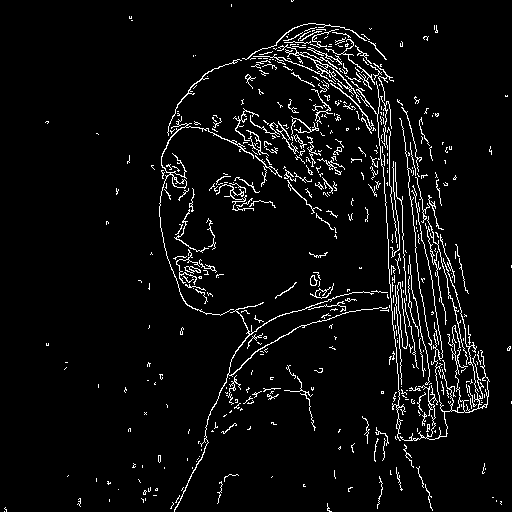

In [2]:
import cv2
import numpy as np
from diffusers.utils import load_image

# Load a base image
base_image_url = "https://hf.co/datasets/huggingface/documentation-images/resolve/main/diffusers/input_image_vermeer.png"
init_image = load_image(base_image_url)

# Convert image to numpy array to generate Canny edges
image_np = np.array(init_image)
low_threshold = 100
high_threshold = 200
edges = cv2.Canny(image_np, low_threshold, high_threshold)

# Convert back to PIL format for the pipeline
from PIL import Image
canny_image = Image.fromarray(edges).convert("RGB")
canny_image


In [3]:
!pip install --upgrade huggingface_hub>=1.23.0,<2.0 # Ensure compatible huggingface_hub version for diffusers
import torch
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler

# 1. Load the specific ControlNet adapter from Hugging Face
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

# 2. Bind it into the Stable Diffusion ControlNet pipeline
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# 3. Use a fast scheduler for efficient generation
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 4. Enable CPU offloading to avoid out-of-memory errors on standard Colab runtimes
pipe.enable_model_cpu_offload()

/bin/bash: line 1: 2.0: No such file or directory


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

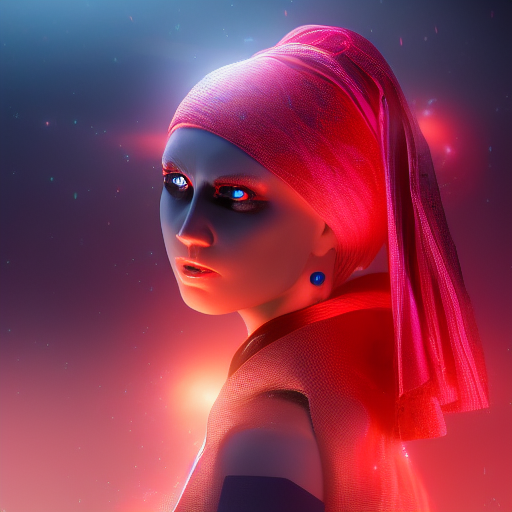

In [4]:
prompt = "a futuristic cyborg woman, highly detailed, sci-fi cyberpunk style, 8k resolution"
negative_prompt = "monochrome, lowres, bad anatomy, worst quality, low quality"

# Run inference
output_image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    image=canny_image,
    num_inference_steps=20,
    controlnet_conditioning_scale=1.0 # Strength of the ControlNet guidance
).images[0]

# Display the output
output_image


In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')


start_path = '/content/drive/MyDrive/returning_back/TestData/Images/'

def list_image_files(directory):
    image_files = []
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_files.append(os.path.join(root, file))
    return image_files

# Get the list of image files
my_images = list_image_files(start_path)

# Display the list of image files found
print(f"Found {len(my_images)} image files:")
for img_file in my_images:
    print(img_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 13 image files:
/content/drive/MyDrive/returning_back/TestData/Images/img1.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img2.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img3.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img4.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img5.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img6.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img7.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img8.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img9.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img10.jpeg
/content/drive/MyDrive/returning_back/TestData/Images/img11.jpg
/content/drive/MyDrive/returning_back/TestData/Images/img12.jpg
/content/drive/MyDrive/returning_back/TestData/Images/img13.jpg


florence 2 model with controlnet example colab

In [6]:
import torch
from PIL import Image
import numpy as np
from transformers import AutoProcessor, AutoModelForCausalLM
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler
# ----------------------------------------------------
# 1. Configuration & Device Setup
# ----------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# ----------------------------------------------------
# 2. Load Microsoft Florence-2 (Large or Base)
# ----------------------------------------------------
#Using florence-2-large for high quality masking, but base works too
florence_id = "microsoft/Florence-2-large"
florence_model = AutoModelForCausalLM.from_pretrained(
    florence_id,
    trust_remote_code=True,
    torch_dtype=torch_dtype
).to(device).eval()
florence_processor = AutoProcessor.from_pretrained(florence_id, trust_remote_code=True)


config.json: 0.00B [00:00, ?B/s]

configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
# ----------------------------------------------------
# 3. Load ControlNet & Stable Diffusion Pipeline
# ----------------------------------------------------
# Using the standard segmentation ControlNet model
controlnet_id = "lllyasviel/sd-controlnet-seg"
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch_dtype).to(device)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch_dtype
).to(device)

# Optimize for speed and memory efficiency on T4 GPU
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_attention_slicing()

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [8]:
# ----------------------------------------------------
# 4. Helper Function: Extract Conditioning via Florence-2
# ----------------------------------------------------
def get_florence_segmentation(image, task_prompt="<REFERRING_EXPRESSION_SEGMENTATION>", text_input="the main object"):
    """
    Prompts Florence-2 to isolate an object and map out a clean segmentation mask.
    """
    if task_prompt == "<REFERRING_EXPRESSION_SEGMENTATION>":
        prompt = task_prompt + text_input
    else:
        prompt = task_prompt

    inputs = florence_processor(text=prompt, images=image, return_tensors="pt").to(device, torch_dtype)

    with torch.no_grad():
        generated_ids = florence_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=1024,
            num_beams=3
        )

    generated_text = florence_processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = florence_processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height)
    )

    # Extract polygon arrays and build a solid binary conditioning mask image
    mask = Image.new("RGB", image.size, "black")
    try:
        # Pull polygons returned from the segmentation prompt
        polygons = parsed_answer[task_prompt]['polygons']
        from PIL import ImageDraw
        draw = ImageDraw.Draw(mask)
        for poly in polygons:
            # Flatten array for PIL polygon layout [x1, y1, x2, y2...]
            flat_poly = [coord for point in poly for coord in point]
            if len(flat_poly) >= 6:
                draw.polygon(flat_poly, fill="white")
    except KeyError:
        print("Target object segment not clearly resolved. Using fallback empty mask.")

    return mask


Executing Florence-2 analysis layer...


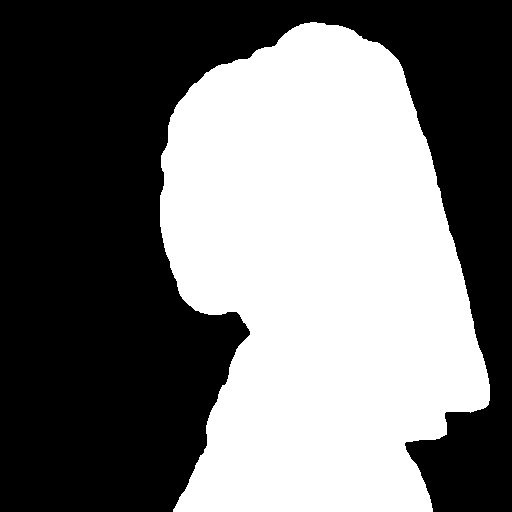

In [12]:

# Create or load a mock source image (Replace with your own PIL Image)
# e.g., image = Image.open("/content/my_input.jpg").convert("RGB").resize((512, 512))
# Load a base image
base_image_url = "https://hf.co/datasets/huggingface/documentation-images/resolve/main/diffusers/input_image_vermeer.png"
source_image = load_image(base_image_url)

#source_image = Image.new("RGB", (512, 512), color=(200, 100, 100))
#display(source_image)
print("Executing Florence-2 analysis layer...")
# Isolate a region using natural language anchoring
conditioning_image = get_florence_segmentation(
    source_image,
    task_prompt="<REFERRING_EXPRESSION_SEGMENTATION>",
    text_input="the center object square"
)

# View the condition extracted by the model
display(conditioning_image)



Passing annotations directly into ControlNet...


  0%|          | 0/25 [00:00<?, ?it/s]

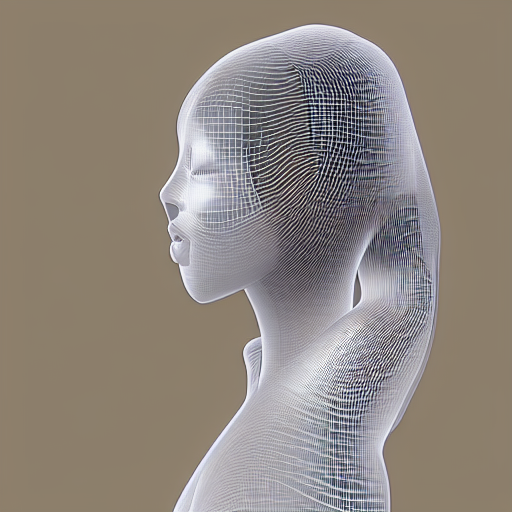

In [17]:
print("Passing annotations directly into ControlNet...")
prompt = "A high-fidelity manja woman face, 8k resolution, futuristic design"
negative_prompt = "blurry, low quality, deformed, worst quality"

generated_output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=conditioning_image,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

# Save output
generated_output.save("controlnet_output.png")
display(generated_output)


Canny edge/depth detection maps instead of segmentation?

In [18]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# ----------------------------------------------------
# 1. Configuration & Mode Selection
# ----------------------------------------------------
# Choose between: "canny" or "depth"
CONTROL_MODE = "depth"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print(selected_mode := f"Setting up Pipeline for Mode: {CONTROL_MODE.upper()}")

# ----------------------------------------------------
# 2. Load the Relevant ControlNet Model Architecture
# ----------------------------------------------------
if CONTROL_MODE == "canny":
    controlnet_id = "lllyasviel/sd-controlnet-canny"
elif CONTROL_MODE == "depth":
    controlnet_id = "lllyasviel/sd-controlnet-depth"

controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch_dtype).to(device)

# Load the base Text-To-Image Model
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch_dtype
).to(device)

# Performance tuning for Google Colab Free Tier (T4)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_attention_slicing()

# ----------------------------------------------------
# 3. Dedicated Preprocessing Map Functions
# ----------------------------------------------------
def extract_canny_edges(pil_image, low_threshold=100, high_threshold=200):
    """
    Computes structural high/low pixel-gradient boundaries from a PIL image.
    """
    cv_img = np.array(pil_image)
    # Run structural Canny filtration
    edges = cv2.Canny(cv_img, low_threshold, high_threshold)
    # ControlNet expects a 3-channel (RGB) structural input map
    edges_rgb = np.concatenate([edges[:, :, None]] * 3, axis=2)
    return Image.fromarray(edges_rgb)

def extract_depth_map(pil_image):
    """
    Utilizes a lightweight MiDaS pipeline to extract depth estimation layouts.
    """
    # Load a quick, highly accurate MiDaS model pipeline via torch hub
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = midas_transforms.flag_transform if hasattr(midas_transforms, 'flag_transform') else midas_transforms.dpt_transform

    cv_img = np.array(pil_image)
    img_tensor = transform(cv_img).to(device)

    with torch.no_grad():
        prediction = midas(img_tensor)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=pil_image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_output = prediction.cpu().numpy()
    # Normalize pixel depth values into a visible 0-255 map array
    depth_min, depth_max = depth_output.min(), depth_output.max()
    normalized_depth = (255 * (depth_output - depth_min) / (depth_max - depth_min)).astype(np.uint8)
    depth_rgb = np.concatenate([normalized_depth[:, :, None]] * 3, axis=2)
    return Image.fromarray(depth_rgb)



Setting up Pipeline for Mode: DEPTH


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating conditioning structure map...
The repository intel-isl_MiDaS does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
The repository rwightman_gen-efficientnet-pytorch does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 265MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


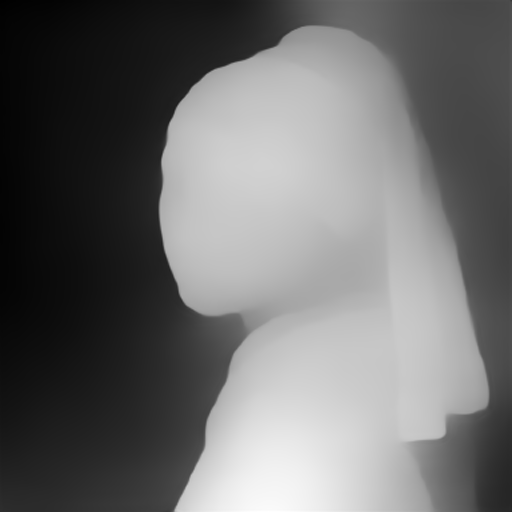

Executing final ControlNet diffusion generation pass...


  0%|          | 0/20 [00:00<?, ?it/s]

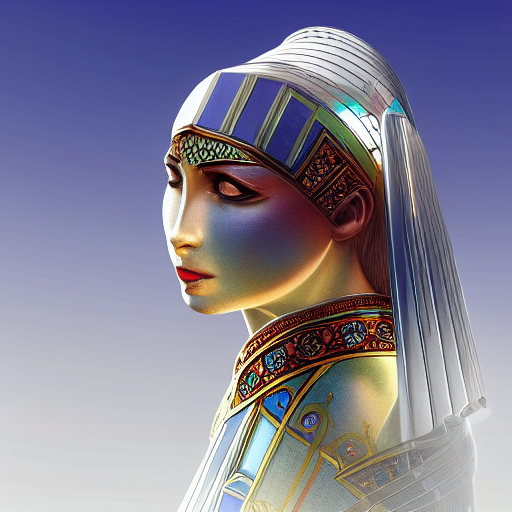

In [19]:

# Create a test gradient background canvas (Replace this with any loaded image)
# e.g., source_image = Image.open("/content/your_photo.jpg").convert("RGB").resize((512, 512))

#source_image = Image.fromarray(np.fromfunction(lambda x, y, z: (x ^ y) % 256, (512, 512, 3), dtype=np.uint8))
base_image_url = "https://hf.co/datasets/huggingface/documentation-images/resolve/main/diffusers/input_image_vermeer.png"
source_image = load_image(base_image_url)

print("Generating conditioning structure map...")
if CONTROL_MODE == "canny":
    conditioning_image = extract_canny_edges(source_image, low_threshold=100, high_threshold=200)
elif CONTROL_MODE == "depth":
    conditioning_image = extract_depth_map(source_image)

# Render structural constraint target image map
display(conditioning_image)

print("Executing final ControlNet diffusion generation pass...")
prompt = "A majestic fantasy castle built into a geometric glass mountain, sharp focus, hyper-detailed digital art"
negative_prompt = "blurry, low quality, human, text, worst composition"

generated_output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=conditioning_image,
    num_inference_steps=20,
    guidance_scale=8.0
).images[0]
# Save output artifacts locally
generated_output.save(f"output_{CONTROL_MODE}.png")
display(generated_output)

how to combine both Canny and Depth maps simultaneously into a Multi-ControlNet pipeline to lock down both edges and 3D depth at the same time

In [20]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# ----------------------------------------------------
# 1. Configuration & Multi-Model Initialization
# ----------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print("Loading dual ControlNet architectures...")

# Load both structural models into a list for Multi-ControlNet
controlnets = [
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch_dtype),
    ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth", torch_dtype=torch_dtype)
]

# Pass the array of ControlNets directly to the unified pipeline
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnets,
    torch_dtype=torch_dtype
).to(device)

# VRAM Optimizations for T4 instances
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_attention_slicing()

# ----------------------------------------------------
# 2. Extract Preprocessing Maps
# ----------------------------------------------------
def get_canny_map(pil_image, low=100, high=200):
    cv_img = np.array(pil_image)
    edges = cv2.Canny(cv_img, low, high)
    edges_rgb = np.concatenate([edges[:, :, None]] * 3, axis=2)
    return Image.fromarray(edges_rgb)

def get_depth_map(pil_image):
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device).eval()
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = midas_transforms.flag_transform if hasattr(midas_transforms, 'flag_transform') else midas_transforms.dpt_transform

    cv_img = np.array(pil_image)
    img_tensor = transform(cv_img).to(device)

    with torch.no_grad():
        prediction = midas(img_tensor)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1), size=pil_image.size[::-1], mode="bicubic", align_corners=False
        ).squeeze()

    depth_output = prediction.cpu().numpy()
    depth_min, depth_max = depth_output.min(), depth_output.max()
    normalized = (255 * (depth_output - depth_min) / (depth_max - depth_min)).astype(np.uint8)
    depth_rgb = np.concatenate([normalized[:, :, None]] * 3, axis=2)
    return Image.fromarray(depth_rgb)


Loading dual ControlNet architectures...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting conditioning stencils...


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Running parallel Multi-ControlNet generation pass...


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


  0%|          | 0/20 [00:00<?, ?it/s]

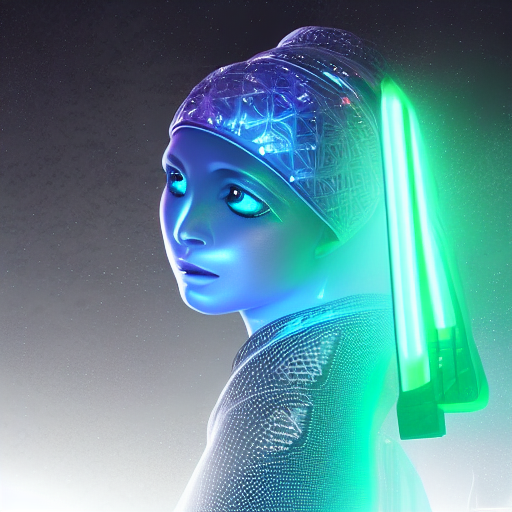

In [21]:
# Create or replace with a real input image
# source_image = Image.open("/content/input.jpg").convert("RGB").resize((512, 512))
#source_image = Image.fromarray(np.fromfunction(lambda x, y, z: (x ^ y) % 256, (512, 512, 3), dtype=np.uint8))
base_image_url = "https://hf.co/datasets/huggingface/documentation-images/resolve/main/diffusers/input_image_vermeer.png"
source_image = load_image(base_image_url)

print("Extracting conditioning stencils...")
canny_condition = get_canny_map(source_image)
depth_condition = get_depth_map(source_image)

# Multi-ControlNet expects maps in the exact order of initialization: [Canny, Depth]
conditioning_images = [canny_condition, depth_condition]

print("Running parallel Multi-ControlNet generation pass...")
prompt = "A crystalline futuristic complex with glowing neon pathways, hyper-detailed cyberpunk design, 8k resolution"
negative_prompt = "blurry, low quality, artifacting, distorted proportions"

# Define the execution weight for each conditioning track independently
# e.g., Let Depth handle composition (0.8) and Canny guide fine lines (0.5)
controlnet_scales = [0.5, 0.8]

generated_output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=conditioning_images, # Pass the list of images
    controlnet_conditioning_scale=controlnet_scales, # Pass the list of scales
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

# Save output artifacts
generated_output.save("multi_controlnet_output.png")
display(generated_output)
